# CC442: Tarea Académica de la Primera Práctica Calificada
## Condicionamiento Espectral y Estabilidad Numérica en el Preprocesamiento

* **Prof.:** Marcos Alania
* **Estudiante:** Cruz Tairo Jhon
* **Dataset asignado: Arrhythmia (UCI)** - 452 instancias x 279 atributos + clase. Valores faltantes marcados con `?`. Clase 01 = ECG normal, 02-15 = arritmias, 16 = no clasificados.

In [36]:
import pandas as pd
import numpy as np

## Carga del dataset

Los 279 atributos: los primeros 15 tienen nombres propios; los restantes siguen un patron por canal ECG (DI, DII, DIII, AVR, AVL, AVF, V1-V6) con medidas de anchura/existencia y de amplitud. La columna 280 es la **clase**.

In [37]:
base_columns = ["Age", "Sex", "Height", "Weight", "QRS_duration", "PR_interval",
               "QT_interval", "T_interval", "P_interval", "QRS_vector", "T_vector",
               "P_vector", "QRST_vector", "J_vector", "Heart_rate"]

channels = ["DI", "DII", "DIII", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]

width_feats = ["Q_width", "R_width", "S_width", "R_prime_width", "S_prime_width",
               "n_intrinsic_deflections", "ragged_R", "diphasic_R", "ragged_P",
               "diphasic_P", "ragged_T", "diphasic_T"]

amplitude_feats = ["JJ_ampl", "Q_ampl", "R_ampl", "S_ampl", "R_prime_ampl",
                   "S_prime_ampl", "P_ampl", "T_ampl", "QRSA", "QRSTA"]

channel_cols = [f"{ch}_{f}" for ch in channels for f in width_feats + amplitude_feats]

columns = base_columns + channel_cols + ["Class"]

df = pd.read_csv("arrhythmia.data", header=None, names=columns, na_values="?")
print(df.shape)

(452, 280)


## 1. ANALISIS ESTRUCTURAL INICIAL

In [38]:
D = df.drop(columns="Class")
n, d = D.shape
print(f"D: {n} x {d}")

nan_cols = D.isna().sum()
nan_cols = nan_cols[nan_cols > 0]
print("Columnas con NaN en %:")
for c, v in nan_cols.sort_values(ascending=False).items():
    print(f"  {c:12s} {v:4d}  ({v/n:.1%})")

const_cols = [c for c in D.columns if D[c].nunique(dropna=True) <= 1]
print(f"\nColumnas de varianza 0 (constantes): {len(const_cols)}")
for c in const_cols:
    print(f"  {c}")

D_op = D.drop(columns=const_cols + ["J_vector"])
print(f"\nD operativa (sin constantes ni J_vector; NaN intactos): {D_op.shape}")

r = np.linalg.matrix_rank(D_op.dropna().to_numpy(dtype=float))
print(f"rank(complete-case de D_op) = {r}  (se reporta solo como referencia historica)")
print("El analisis espectral de C/D/E usa la matriz imputada de 452 filas (seccion C).")


D: 452 x 279
Columnas con NaN en %:
  J_vector      376  (83.2%)
  P_vector       22  (4.9%)
  T_vector        8  (1.8%)
  QRST_vector     1  (0.2%)
  Heart_rate      1  (0.2%)

Columnas de varianza 0 (constantes): 17
  DI_S_prime_width
  DIII_ragged_P
  DIII_ragged_T
  AVR_S_width
  AVF_ragged_R
  AVF_diphasic_R
  AVF_R_ampl
  AVF_R_prime_ampl
  AVF_P_ampl
  AVF_QRSA
  V1_S_prime_width
  V1_diphasic_P
  V1_ragged_T
  V1_S_prime_ampl
  V3_Q_ampl
  V6_diphasic_R
  V6_S_prime_ampl

D operativa (sin constantes ni J_vector; NaN intactos): (452, 261)
rank(complete-case de D_op) = 252  (se reporta solo como referencia historica)
El analisis espectral de C/D/E usa la matriz imputada de 452 filas (seccion C).


In [39]:
D = D_op.dropna().to_numpy(dtype=float)

rank_D = np.linalg.matrix_rank(D)

print(f"rank(D) = {rank_D}")
print(f"dimensiones = {D.shape}")
print(f"Rango completo: {rank_D == min(D.shape)}")


rank(D) = 252
dimensiones = (420, 261)
Rango completo: False


In [40]:
Xc = D_op.dropna().to_numpy(dtype=float)
Xc = Xc - Xc.mean(axis=0)
G = Xc.T @ Xc
ev = np.linalg.eigvalsh(G)
lam_max, lam_min = ev[-1], ev[0]
tol = np.finfo(float).eps * max(Xc.shape) * lam_max

print(f"lambda_max = {lam_max:.3e}")
print(f"lambda_min = {lam_min:.3e}")
print(f"Autovalores <= 0: {int((ev <= 0).sum())}  | < tol (eps*maxsh*lammax): {int((ev < tol).sum())}")

nz = ev[ev > tol]
kappa = nz.max() / nz.min() if len(nz) else np.inf
print(f"kappa(X^T X centrado) efectivo = {kappa:.3e}  | log10(kappa) = {np.log10(kappa):.2f}")

print("Top 5 autovalores:", [f"{x:.2e}" for x in ev[::-1][:5]])
print("Bottom 5 (no nulos):", [f"{x:.2e}" for x in nz[:5]])

Xr = D_op.dropna().to_numpy(dtype=float)
Gr = Xr.T @ Xr
evr = np.linalg.eigvalsh(Gr)
tolr = np.finfo(float).eps * max(Xr.shape) * evr[-1]
nzr = evr[evr > tolr]
kappa_r = nzr.max() / nzr.min()
print(f"kappa Gram SIN centrar (referencia) = {kappa_r:.3e}  (log10 = {np.log10(kappa_r):.2f})")


lambda_max = 2.851e+06
lambda_min = -6.561e-12
Autovalores <= 0: 4  | < tol (eps*maxsh*lammax): 9
kappa(X^T X centrado) efectivo = 4.044e+12  | log10(kappa) = 12.61
Top 5 autovalores: ['2.85e+06', '1.80e+06', '1.67e+06', '1.39e+06', '8.96e+05']
Bottom 5 (no nulos): ['7.05e-07', '1.01e-04', '2.42e-04', '7.03e-04', '4.75e-03']
kappa Gram SIN centrar (referencia) = 1.292e+12  (log10 = 12.11)


lambda_max(Sigma) = 6.788e+03
lambda_min(Sigma) = -9.222e-15
Autovalores <= 0: 5  | < tol: 9
kappa(Sigma) efectivo = 4.044e+12  | log10 = 12.61
rank(Sigma) = 252 < 261
det(Sigma) ~ 10^-123.9
1er autovalor concentra 16.70% de la varianza
5 autovalores acumulan 50.41%
20 autovalores acumulan 85.67%


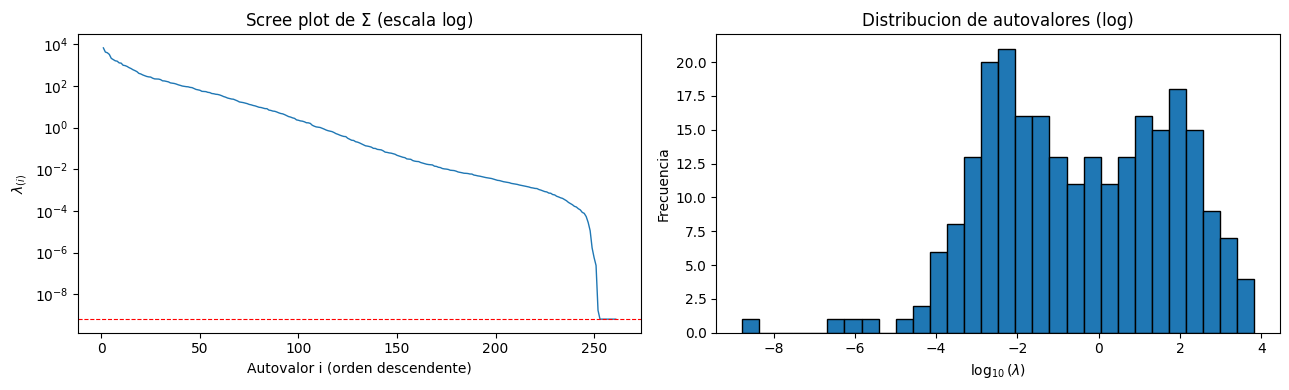

In [41]:
# Sigma poblacional (1/n) sobre el complete-case, convencion ddof=0 unificada con 4.3/4.5
# analisis de la matriz de covarianza
D_cc = D_op.dropna()
Sigma = np.cov(D_cc.to_numpy(dtype=float), rowvar=False, ddof=0)
ev = np.linalg.eigvalsh(Sigma)
n, d = D_cc.shape
lam_max = ev[-1]
tol = np.finfo(float).eps * max(n, d) * lam_max

print(f"lambda_max(Sigma) = {lam_max:.3e}")
print(f"lambda_min(Sigma) = {ev[0]:.3e}")
print(f"Autovalores <= 0: {int((ev <= 0).sum())}  | < tol: {int((ev < tol).sum())}")

nz = ev[ev > tol]
kappa_S = nz.max() / nz.min() if len(nz) else np.inf
print(f"kappa(Sigma) efectivo = {kappa_S:.3e}  | log10 = {np.log10(kappa_S):.2f}")

rk = np.linalg.matrix_rank(Sigma)
nz0 = int((np.abs(ev) <= tol).sum())
pos_ev = ev[ev > tol]
log_det = float(np.sum(np.log10(np.abs(pos_ev))))
print(f"rank(Sigma) = {rk} < {d}")
print(f"det(Sigma) ~ 10^{log_det:.1f}")

total_var = pos_ev.sum()  # solo autovalores positivos (exclude numerical noise)
print(f"1er autovalor concentra {ev[-1]/total_var:.2%} de la varianza")
print(f"5 autovalores acumulan {ev[-5:].sum()/total_var:.2%}")
print(f"20 autovalores acumulan {ev[-20:].sum()/total_var:.2%}")

import matplotlib.pyplot as plt

lam_desc = np.clip(ev[::-1], tol, None)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, d + 1), lam_desc, lw=1)
ax1.axhline(tol, ls="--", c="red", lw=0.8)
ax1.set_yscale("log")
ax1.set_xlabel("Autovalor i (orden descendente)")
ax1.set_ylabel("$\\lambda_{(i)}$")
ax1.set_title("Scree plot de $\\Sigma$ (escala log)")

ax2.hist(np.log10(ev[ev > tol]), bins=30, edgecolor="black")
ax2.set_xlabel("$\\log_{10}(\\lambda)$")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribucion de autovalores (log)")

plt.tight_layout()
plt.show()


## Conclusiones

- La matriz de covarianzas presenta un **condicionamiento muy deficiente**, con:
  - $\kappa(\Sigma) \approx 4.04\times10^{12}$.
  - 9 autovalores prácticamente nulos.
  - $\operatorname{rank}(\Sigma)=252$ frente a 261 variables.
- Esto evidencia **fuerte multicolinealidad y redundancia** entre las variables.
- La varianza no está concentrada únicamente en unas pocas dimensiones:
  - 20 componentes explican **85.79%** de la varianza.
  - 50 componentes explican **97.53%**.
- El scree plot muestra una caída progresiva y una caída muy pronunciada en las últimas componentes, asociada a las dimensiones casi redundantes.
- **PCA es factible y recomendable como estrategia de reducción dimensional**: permite pasar de 261 a aproximadamente 50 componentes conservando el **97.53% de la varianza**, además de eliminar las dimensiones prácticamente nulas.
- Para un modelo predictivo, el número final de componentes debería validarse también según el **desempeño predictivo**, no solo por varianza explicada.


In [42]:
import json, os
os.makedirs("data", exist_ok=True)

excluidas = const_cols + ["J_vector"]
with open("data/columnas_excluidas.json", "w", encoding="utf-8") as f:
    json.dump(excluidas, f, indent=2, ensure_ascii=False)
print(f"columnas_excluidas.json: {len(excluidas)} columnas guardadas")

export_df = pd.concat([D_op, df["Class"]], axis=1)
export_df.to_parquet("data/arrhythmia_preprocesado.parquet", index=False)
print(f"arrhythmia_preprocesado.parquet: {export_df.shape} guardado")

columnas_excluidas.json: 18 columnas guardadas
arrhythmia_preprocesado.parquet: (452, 262) guardado
